# 아파트 가격 영향 변수 Top 5 분석 

## 1. 라이브러리 임포트

In [44]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor


## 2. 데이터 로드 및 타깃 생성

In [45]:
# 선형회귀 / 라쏘 / 릿지용 데이터
df_all = pd.read_csv(r'C:\3_1_DataMining\NewCity-Apartment-Price-Prediction\data\new_city.csv', encoding='utf-8-sig')
df = df_all[df_all['도시명'].isin(['운정', '광교', '판교'])].copy()

df['거래금액(만원)'] = df['거래금액(만원)'].str.replace(',', '').astype(int)
df['m2당가격'] = df['거래금액(만원)'] / df['전용면적(㎡)']

df_train = df.copy()
df_test  = pd.read_csv(r'C:\3_1_DataMining\NewCity-Apartment-Price-Prediction\data\geomdan_merged.csv', encoding='utf-8-sig')

df_geomdan_train = df_test[df_test['계약연도'] <= 2023].copy()
df_test          = df_test[df_test['계약연도'] >= 2024].copy()
df_train         = pd.concat([df_train, df_geomdan_train], ignore_index=True)


print('데이터 크기(new_city):', df_train.shape)
print('계약연도 범위:', df_train['계약연도'].min(), '~', df_train['계약연도'].max())
print('도시명:', df_train['도시명'].unique())


# RandomForest용 데이터
df_geo = pd.read_csv(r'C:\3_1_DataMining\NewCity-Apartment-Price-Prediction\data\real_new_city.csv', encoding='utf-8-sig')

df_geo['거래금액(만원)'] = df_geo['거래금액(만원)'].str.replace(',', '').astype(int)
df_geo['m2당가격'] = df_geo['거래금액(만원)'] / df_geo['전용면적(㎡)']

print('\n데이터 크기(real_new_city):', df_geo.shape)
print('계약연도 범위:', df_geo['계약연도'].min(), '~', df_geo['계약연도'].max())
print('도시명:', df_geo['도시명'].unique())


데이터 크기(new_city): (65688, 35)
계약연도 범위: 2006 ~ 2026
도시명: <StringArray>
['판교', '광교', '운정', '검단']
Length: 4, dtype: str

데이터 크기(real_new_city): (126375, 29)
계약연도 범위: 2006 ~ 2026
도시명: <StringArray>
['청라', '송도', '판교', '광교', '운정', '검단']
Length: 6, dtype: str


## 3. 피처 선택 및 이상치 제거

In [46]:
features = [
    '건축년도',
    '층',
    '지하철호선개수',
    '기차역까지의거리',
    '가장 가까운 지하철역까지의 거리',
    '가장 가까운 IC와의 거리',
    '발표후경과년수',
    'CPI',
    '계약연도',
    '서울도심거리',
    '단지별_세대수',
    '도시별_세대수',
]

# new_city.csv 전처리 (선형회귀 / 라쏘 / 릿지)
df_train = df_train[df_train['전용면적(㎡)'] >= 33]

before = len(df_train)
df_train = df_train[df_train['발표후경과년수'] >= 3]
print(f"[new_city] 발표후경과년수 3 미만 제거: {before - len(df_train)}개 → 남은 데이터: {len(df_train)}개")

mean = df_train['m2당가격'].mean()
std  = df_train['m2당가격'].std()
df_train = df_train[(((df_train['m2당가격'] - mean) / std).abs() <= 2)]
df_train = df_train.dropna(subset=features + ['m2당가격'])
print(f'[new_city] 사용 데이터: {len(df_train)}행  /  피처: {len(features)}개')


# new_city_within_geomdan.csv 전처리 (KNN / RandomForest) 
df_geo = df_geo[df_geo['전용면적(㎡)'] >= 33]

before_geo = len(df_geo)
df_geo = df_geo[df_geo['발표후경과년수'] >= 3]
print(f"\n[geomdan] 발표후경과년수 3 미만 제거: {before_geo - len(df_geo)}개 → 남은 데이터: {len(df_geo)}개")

mean_geo = df_geo['m2당가격'].mean()
std_geo  = df_geo['m2당가격'].std()
df_geo   = df_geo[(((df_geo['m2당가격'] - mean_geo) / std_geo).abs() <= 2)]
df_geo   = df_geo.dropna(subset=features + ['m2당가격'])
print(f'[geomdan] 사용 데이터: {len(df_geo)}행  /  피처: {len(features)}개')


[new_city] 발표후경과년수 3 미만 제거: 3863개 → 남은 데이터: 61707개
[new_city] 사용 데이터: 33990행  /  피처: 12개

[geomdan] 발표후경과년수 3 미만 제거: 3863개 → 남은 데이터: 122221개
[geomdan] 사용 데이터: 116929행  /  피처: 12개


## 4. 훈련·테스트 분할

In [47]:
# 선형회귀 / 라쏘 / 릿지용 분할
train_input, test_input, train_target, test_target = train_test_split(
    df_train[features], df_train['m2당가격'], test_size=0.2, random_state=42
)
print(f'[new_city] 훈련셋: {len(train_input)}행 / 테스트셋: {len(test_input)}행')


# RandomForest용 분할
train_input_geo, test_input_geo, train_target_geo, test_target_geo = train_test_split(
    df_geo[features], df_geo['m2당가격'], test_size=0.2, random_state=42
)
print(f'[geomdan] 훈련셋: {len(train_input_geo)}행 / 테스트셋: {len(test_input_geo)}행')


[new_city] 훈련셋: 27192행 / 테스트셋: 6798행
[geomdan] 훈련셋: 93543행 / 테스트셋: 23386행


## 5. StandardScaler 정규화 

선형 모델과 KNN 모두 스케일 영향을 받으므로 표준화 필수

In [48]:
# 선형회귀 / 라쏘 / 릿지용 스케일링
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled  = ss.transform(test_input)


# RandomForest용 스케일링
ss_geo = StandardScaler()
ss_geo.fit(train_input_geo)
train_scaled_geo = ss_geo.transform(train_input_geo)
test_scaled_geo  = ss_geo.transform(test_input_geo)


## 6. 방법 1: 선형 회귀 계수 

In [49]:
lr = LinearRegression()
lr.fit(train_scaled, train_target)

print(f'[방법1] 훈련 R²: {lr.score(train_scaled, train_target):.4f}  '
      f'테스트 R²: {lr.score(test_scaled, test_target):.4f}')

m1 = pd.DataFrame({
    '변수': features,
    '방법1_점수': np.abs(lr.coef_)
}).sort_values('방법1_점수', ascending=False).reset_index(drop=True)
m1['방법1_순위'] = range(1, len(m1) + 1)

print('\n[방법1] 순위:')
print(m1[['변수','방법1_점수','방법1_순위']].to_string())

[방법1] 훈련 R²: 0.7985  테스트 R²: 0.8003

[방법1] 순위:
                   변수       방법1_점수  방법1_순위
0             발표후경과년수  2420.916738       1
1                계약연도  2286.657110       2
2            기차역까지의거리   393.254995       3
3              서울도심거리   189.063326       4
4             도시별_세대수   108.097655       5
5   가장 가까운 지하철역까지의 거리    46.116887       6
6                건축년도    45.432327       7
7                 CPI    21.253405       8
8             단지별_세대수    19.763124       9
9                   층     8.773283      10
10            지하철호선개수     4.582799      11
11     가장 가까운 IC와의 거리     1.888477      12


## 7. 방법 2: 라쏘 회귀 계수

In [50]:
lasso = Lasso(alpha=0.001, max_iter=1000000)
lasso.fit(train_scaled, train_target)

print(f'[방법2] 훈련 R²: {lasso.score(train_scaled, train_target):.4f}  '
      f'테스트 R²: {lasso.score(test_scaled, test_target):.4f}')
print(f'  계수가 0인 변수 수: {np.sum(lasso.coef_ == 0)}개')

m2 = pd.DataFrame({
    '변수': features,
    '방법2_점수': np.abs(lasso.coef_)
}).sort_values('방법2_점수', ascending=False).reset_index(drop=True)
m2['방법2_순위'] = range(1, len(m2) + 1)

print('\n[방법2] 순위:')
print(m2[['변수','방법2_점수','방법2_순위']].to_string())

[방법2] 훈련 R²: 0.7985  테스트 R²: 0.8003
  계수가 0인 변수 수: 0개

[방법2] 순위:
                   변수       방법2_점수  방법2_순위
0             발표후경과년수  2413.514025       1
1                계약연도  2279.261591       2
2            기차역까지의거리   391.345097       3
3              서울도심거리   188.461406       4
4             도시별_세대수   109.339596       5
5   가장 가까운 지하철역까지의 거리    46.109837       6
6                건축년도    45.435318       7
7                 CPI    21.262174       8
8             단지별_세대수    19.776780       9
9                   층     8.793469      10
10            지하철호선개수     4.599520      11
11     가장 가까운 IC와의 거리     1.991585      12


## 8. 방법 3: 릿지 회귀 계수 

In [51]:
ridge = Ridge(alpha=0.001)
ridge.fit(train_scaled, train_target)

print(f'[방법3] 훈련 R²: {ridge.score(train_scaled, train_target):.4f}  '
      f'테스트 R²: {ridge.score(test_scaled, test_target):.4f}')

m3 = pd.DataFrame({
    '변수': features,
    '방법3_점수': np.abs(ridge.coef_)
}).sort_values('방법3_점수', ascending=False).reset_index(drop=True)
m3['방법3_순위'] = range(1, len(m3) + 1)

print('\n[방법3] 순위:')
print(m3[['변수','방법3_점수','방법3_순위']].to_string())

[방법3] 훈련 R²: 0.7985  테스트 R²: 0.8003

[방법3] 순위:
                   변수       방법3_점수  방법3_순위
0             발표후경과년수  2420.314975       1
1                계약연도  2286.055029       2
2            기차역까지의거리   393.098487       3
3              서울도심거리   189.014500       4
4             도시별_세대수   108.202504       5
5   가장 가까운 지하철역까지의 거리    46.117343       6
6                건축년도    45.432610       7
7                 CPI    21.255074       8
8             단지별_세대수    19.764127       9
9                   층     8.774965      10
10            지하철호선개수     4.584851      11
11     가장 가까운 IC와의 거리     1.899689      12


## 9. 방법 4: RandomForest 특성 중요도 

In [52]:
# RandomForest: new_city_within_geomdan.csv 사용
rf = RandomForestRegressor(n_jobs=-1, random_state=42)
rf.fit(train_scaled_geo, train_target_geo)

print(f'[방법4] 훈련 R²: {rf.score(train_scaled_geo, train_target_geo):.4f}  '
      f'테스트 R²: {rf.score(test_scaled_geo, test_target_geo):.4f}')

m4 = pd.DataFrame({
    '변수': features,
    '방법4_점수': rf.feature_importances_
}).sort_values('방법4_점수', ascending=False).reset_index(drop=True)
m4['방법4_순위'] = range(1, len(m4) + 1)

print('\n[방법4] 순위:')
print(m4[['변수','방법4_점수','방법4_순위']].to_string())


[방법4] 훈련 R²: 0.9749  테스트 R²: 0.9395

[방법4] 순위:
                   변수    방법4_점수  방법4_순위
0                건축년도  0.502090       1
1             도시별_세대수  0.127241       2
2             발표후경과년수  0.116218       3
3              서울도심거리  0.084932       4
4            기차역까지의거리  0.045849       5
5                   층  0.025460       6
6                계약연도  0.022585       7
7   가장 가까운 지하철역까지의 거리  0.022191       8
8                 CPI  0.019941       9
9             단지별_세대수  0.017166      10
10     가장 가까운 IC와의 거리  0.015311      11
11            지하철호선개수  0.001015      12


## 10. 4가지 방법 통합 순위

In [54]:
merged = m1[['변수','방법1_순위']].copy()
merged = merged.merge(m2[['변수','방법2_순위']], on='변수')
merged = merged.merge(m3[['변수','방법3_순위']], on='변수')
merged = merged.merge(m4[['변수','방법4_순위']], on='변수')

merged['평균순위'] = (
    merged['방법1_순위'] +
    merged['방법2_순위'] +
    merged['방법3_순위'] +
    merged['방법4_순위'] 
) / 4

merged = merged.sort_values('평균순위').reset_index(drop=True)
merged.index += 1

print('=== 4가지 방법 통합 순위 ===')
print(merged.to_string())


=== 4가지 방법 통합 순위 ===
                   변수  방법1_순위  방법2_순위  방법3_순위  방법4_순위   평균순위
1             발표후경과년수       1       1       1       3   1.50
2                계약연도       2       2       2       7   3.25
3            기차역까지의거리       3       3       3       5   3.50
4              서울도심거리       4       4       4       4   4.00
5             도시별_세대수       5       5       5       2   4.25
6                건축년도       7       7       7       1   5.50
7   가장 가까운 지하철역까지의 거리       6       6       6       8   6.50
8                 CPI       8       8       8       9   8.25
9                   층      10      10      10       6   9.00
10            단지별_세대수       9       9       9      10   9.25
11            지하철호선개수      11      11      11      12  11.25
12     가장 가까운 IC와의 거리      12      12      12      11  11.75


## 11. 최종 결과: Top 5

In [57]:
top5 = merged.head(5)

print()
print('=' * 110)
print('  아파트 가격에 가장 큰 영향을 주는 변수 Top 5  (4가지 방법 통합)')
print('=' * 110)
for i, row in top5.iterrows():
    r1 = int(row['방법1_순위'])
    r2 = int(row['방법2_순위'])
    r3 = int(row['방법3_순위'])
    r4 = int(row['방법4_순위'])
    print(f'  {i}위. {row["변수"]:28s}  '
          f'평균순위: {row["평균순위"]:.1f}  '
          f'(선형회귀:{r1} / 라쏘:{r2} / 릿지:{r3} / RandomForest:{r4})')
print('=' * 110)



  아파트 가격에 가장 큰 영향을 주는 변수 Top 5  (4가지 방법 통합)
  1위. 발표후경과년수                       평균순위: 1.5  (선형회귀:1 / 라쏘:1 / 릿지:1 / RandomForest:3)
  2위. 계약연도                          평균순위: 3.2  (선형회귀:2 / 라쏘:2 / 릿지:2 / RandomForest:7)
  3위. 기차역까지의거리                      평균순위: 3.5  (선형회귀:3 / 라쏘:3 / 릿지:3 / RandomForest:5)
  4위. 서울도심거리                        평균순위: 4.0  (선형회귀:4 / 라쏘:4 / 릿지:4 / RandomForest:4)
  5위. 도시별_세대수                       평균순위: 4.2  (선형회귀:5 / 라쏘:5 / 릿지:5 / RandomForest:2)


## 12. 방법별 Top 5 비교 시각화

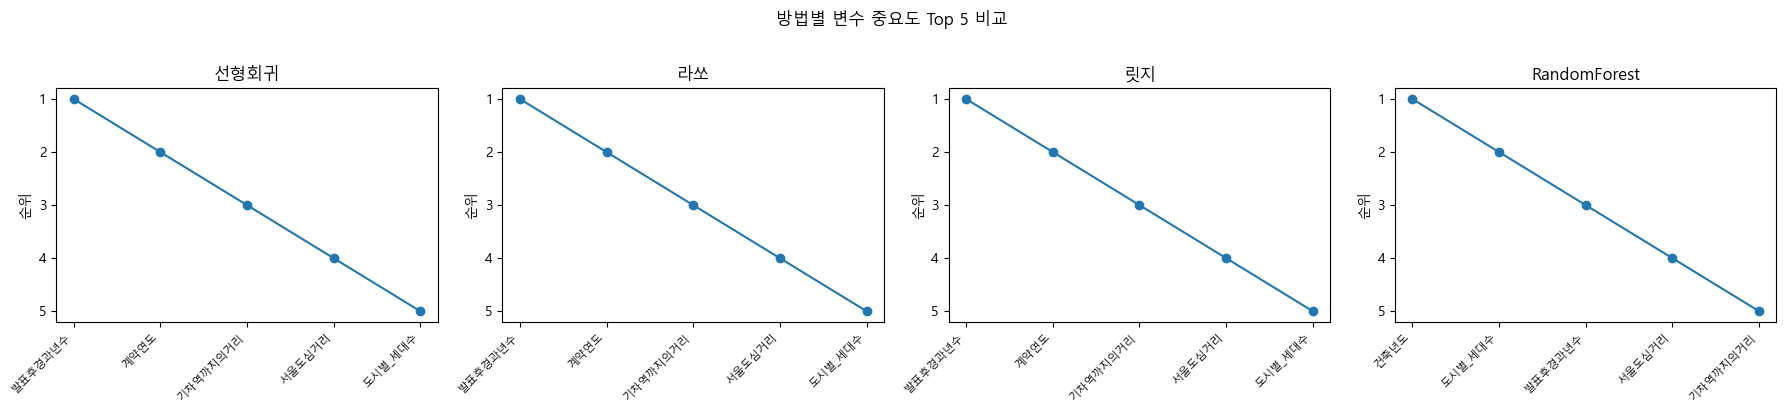

In [59]:
방법목록 = ['방법1_순위', '방법2_순위', '방법3_순위', '방법4_순위']
방법이름 = ['선형회귀', '라쏘', '릿지', 'RandomForest']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col, name in zip(axes, 방법목록, 방법이름):
    top = merged.sort_values(col).head(5)
    ax.plot(range(1, 6), top[col].values, 'o-')
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(top['변수'].values, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('순위')
    ax.set_title(name)
    ax.invert_yaxis()

plt.suptitle('방법별 변수 중요도 Top 5 비교', y=1.02)
plt.tight_layout()
plt.show()


## 13. 최종 Top 5 시각화

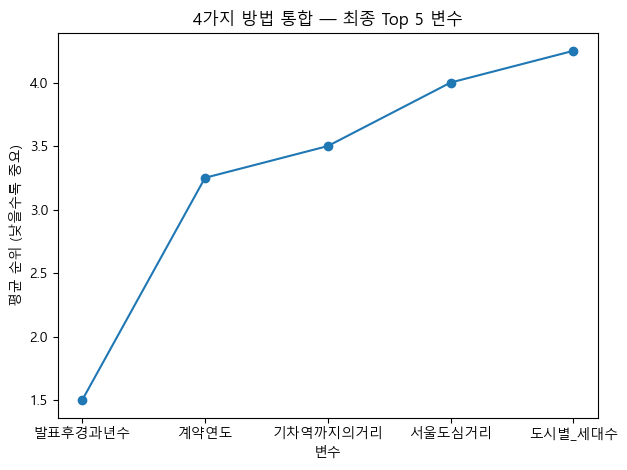

In [60]:
# 최종 Top 5 평균 순위 시각화
plt.plot(top5['변수'], top5['평균순위'], 'o-')
plt.xlabel('변수')
plt.ylabel('평균 순위 (낮을수록 중요)')
plt.title('4가지 방법 통합 — 최종 Top 5 변수')
plt.tight_layout()
plt.show()
